<!-- Cell purpose: Introduce the UVC unembryonated egg analysis notebook. -->

# UVC Unembryonated Egg Analysis (`analysis_UVC_unembryonated.ipynb`)

This notebook follows the same analysis workflow used for SHG/800nm, adapted to UVC datasets with pooled controls.

Rules applied:
- Pooled controls: `2024-03-04`, `2024-03-20`, `2025-06-12`
- Exclude `degenerated` eggs
- Include `arrested` and `leak` eggs up to the last recorded stage time
- Candidate UVC datasets checked here: `UVC-6W-2s`, `UVC-6W-5s`, `UVC-6W-10s`, `UVC-6W-30s`



In [1]:
# List the UVC candidate groups to verify

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/01_master_unembryonated.csv"
CONTROL_DATES = [
    pd.Timestamp("2024-03-04"),
    pd.Timestamp("2024-03-20"),
    pd.Timestamp("2025-06-12"),
]

UVC_CANDIDATES = [
    {"label": "uvc_6W_2s", "system": "uvc", "wl_nm": 254, "power_mW": 6, "exposure_s": 2},
    {"label": "uvc_6W_5s", "system": "uvc", "wl_nm": 254, "power_mW": 6, "exposure_s": 5},
    {"label": "uvc_6W_10s", "system": "uvc", "wl_nm": 254, "power_mW": 6, "exposure_s": 10},
    {"label": "uvc_6W_30s", "system": "uvc", "wl_nm": 254, "power_mW": 6, "exposure_s": 30},
]

VALID_OUTCOMES = {"l3_reached", "arrested", "leak"}
MIN_NON_NULL_STAGE_ROWS = 15
MIN_NON_NULL_PER_STAGE = 10

PLOTS_DIR = Path("254nm/unembryonated/plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("254nm/unembryonated/tables/")
TABLES_DIR.mkdir(parents=True, exist_ok=True)



In [2]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan



In [3]:
# Load and clean source table

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "outcome", "flags"]:
    df[col] = df[col].map(to_snake_or_nan)

for col in ["control", "wl_nm", "power_mW", "exposure_s", "t_start_h", "t_2c_h", "t_4c_h", "t_bean_h", "t_move_h"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded: {csv_file}")
print(f"Rows: {len(df)}")



Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/01_master_unembryonated.csv
Rows: 866


In [4]:
# Candidate UVC dataset check (data availability + stage-time coverage)

uvc_base = df[(df["system"] == "uvc") & (df["wl_nm"] == 254)].copy()

rows = []
for cfg in UVC_CANDIDATES:
    mask = (
        (uvc_base["system"] == cfg["system"])
        & (uvc_base["wl_nm"] == cfg["wl_nm"])
        & (uvc_base["power_mW"] == cfg["power_mW"])
        & (uvc_base["exposure_s"] == cfg["exposure_s"])
    )
    sub = uvc_base[mask].copy()
    n_total = len(sub)

    sub_valid = sub[sub["outcome"].isin(VALID_OUTCOMES)].copy()
    n_valid = len(sub_valid)

    stage_cols = ["t_2c_h", "t_4c_h", "t_bean_h", "t_move_h"]
    stage_non_null = {c: int(sub_valid[c].notna().sum()) for c in stage_cols}
    n_any_stage = int(sub_valid[stage_cols].notna().any(axis=1).sum())

    include = (
        n_any_stage >= MIN_NON_NULL_STAGE_ROWS
        and all(stage_non_null[c] >= MIN_NON_NULL_PER_STAGE for c in stage_cols)
    )

    rows.append(
        {
            "label": cfg["label"],
            "system": cfg["system"],
            "wl_nm": cfg["wl_nm"],
            "power_mW": cfg["power_mW"],
            "exposure_s": cfg["exposure_s"],
            "n_total": n_total,
            "n_valid_non_degenerated": n_valid,
            "n_any_stage_time": n_any_stage,
            "n_t_2c": stage_non_null["t_2c_h"],
            "n_t_4c": stage_non_null["t_4c_h"],
            "n_t_bean": stage_non_null["t_bean_h"],
            "n_t_move": stage_non_null["t_move_h"],
            "include_in_analysis": bool(include),
        }
    )

uvc_candidate_profile_df = pd.DataFrame(rows)
display(uvc_candidate_profile_df)

out_csv = TABLES_DIR / "uvc_candidate_profile.csv"
uvc_candidate_profile_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")

selected_uvc_configs = [
    cfg for cfg in UVC_CANDIDATES
    if bool(uvc_candidate_profile_df.loc[uvc_candidate_profile_df["label"] == cfg["label"], "include_in_analysis"].iloc[0])
]
selected_uvc_labels = [cfg["label"] for cfg in selected_uvc_configs]
print("Selected UVC datasets:", selected_uvc_labels)
if not selected_uvc_configs:
    raise ValueError("No UVC candidate passed stage-time minimum threshold.")



,label,system,wl_nm,power_mW,exposure_s,n_total,n_valid_non_degenerated,n_any_stage_time,n_t_2c,n_t_4c,n_t_bean,n_t_move,include_in_analysis
0,uvc_6W_2s,uvc,254,6,2,36,31,31,31,31,31,31,True
1,uvc_6W_5s,uvc,254,6,5,36,33,29,29,29,27,27,True
2,uvc_6W_10s,uvc,254,6,10,36,27,13,13,13,10,10,False
3,uvc_6W_30s,uvc,254,6,30,38,38,4,4,2,0,0,False


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_candidate_profile.csv
Selected UVC datasets: ['uvc_6W_2s', 'uvc_6W_5s']


In [5]:
# Build stage-time analysis table for selected UVC datasets + pooled controls

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}
stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

frames = []
for cfg in selected_uvc_configs:
    sub = df[
        (df["system"] == cfg["system"])
        & (df["wl_nm"] == cfg["wl_nm"])
        & (df["power_mW"] == cfg["power_mW"])
        & (df["exposure_s"] == cfg["exposure_s"])
        & (df["outcome"].isin(VALID_OUTCOMES))
    ].copy()
    sub["group"] = cfg["label"]
    sub["duration_label"] = f"{int(cfg['exposure_s'])}s"
    frames.append(sub)

ctrl = df[
    (df["control"] == 1)
    & (df["start_date"].isin(CONTROL_DATES))
    & (df["outcome"].isin(VALID_OUTCOMES))
].copy()
ctrl["group"] = "pooled_control"
ctrl["duration_label"] = "control"
frames.append(ctrl)

uvc_stage_df = pd.concat(frames, ignore_index=True)
for s in ["2c", "4c", "bean", "move"]:
    uvc_stage_df[f"dt_{s}"] = uvc_stage_df[f"t_{s}_h"] - uvc_stage_df["t_start_h"]

uvc_stage_long_df = (
    uvc_stage_df.melt(
        id_vars=["egg_uid", "well_id", "start_date", "outcome", "group", "duration_label"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)
uvc_stage_long_df["stage"] = uvc_stage_long_df["stage"].map(stage_label_map)
uvc_stage_long_df["stage"] = pd.Categorical(uvc_stage_long_df["stage"], categories=stage_order, ordered=True)

display(uvc_stage_long_df.head())

out_csv = TABLES_DIR / "uvc_stage_times_long_selected_and_pooled_control.csv"
uvc_stage_long_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,egg_uid,well_id,start_date,outcome,group,duration_label,stage,dt_h
0,795,1,2025-06-10,l3_reached,uvc_6W_2s,2s,2-cell,72.8
1,796,1,2025-06-11,l3_reached,uvc_6W_2s,2s,2-cell,161.8
2,797,1,2025-06-12,l3_reached,uvc_6W_2s,2s,2-cell,27.1
3,798,2,2025-06-10,l3_reached,uvc_6W_2s,2s,2-cell,46.5
4,799,2,2025-06-11,l3_reached,uvc_6W_2s,2s,2-cell,50.1


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_stage_times_long_selected_and_pooled_control.csv


Figure: Raincloud comparison of embryonation-stage timing across selected UVC irradiation datasets versus pooled controls. Panels show each selected UVC exposure group and pooled controls (control dates: 2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis is elapsed time in hours from incubation start, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines distribution shape (half-violin), spread and central tendency (box/IQR), and individual observations, with bold labels indicating stage-specific medians. Included eggs are restricted to VALID_OUTCOMES (non-degenerated outcomes defined earlier); stage-wise sample sizes can differ because missing stage timestamps are excluded.


/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_name, group_df in self.plot_data.groupby(grouping_vars):
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/arkadi/Desktop/lia-sth/.venv/lib/python3.11/site-packages/ptitprince/PtitPrince.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

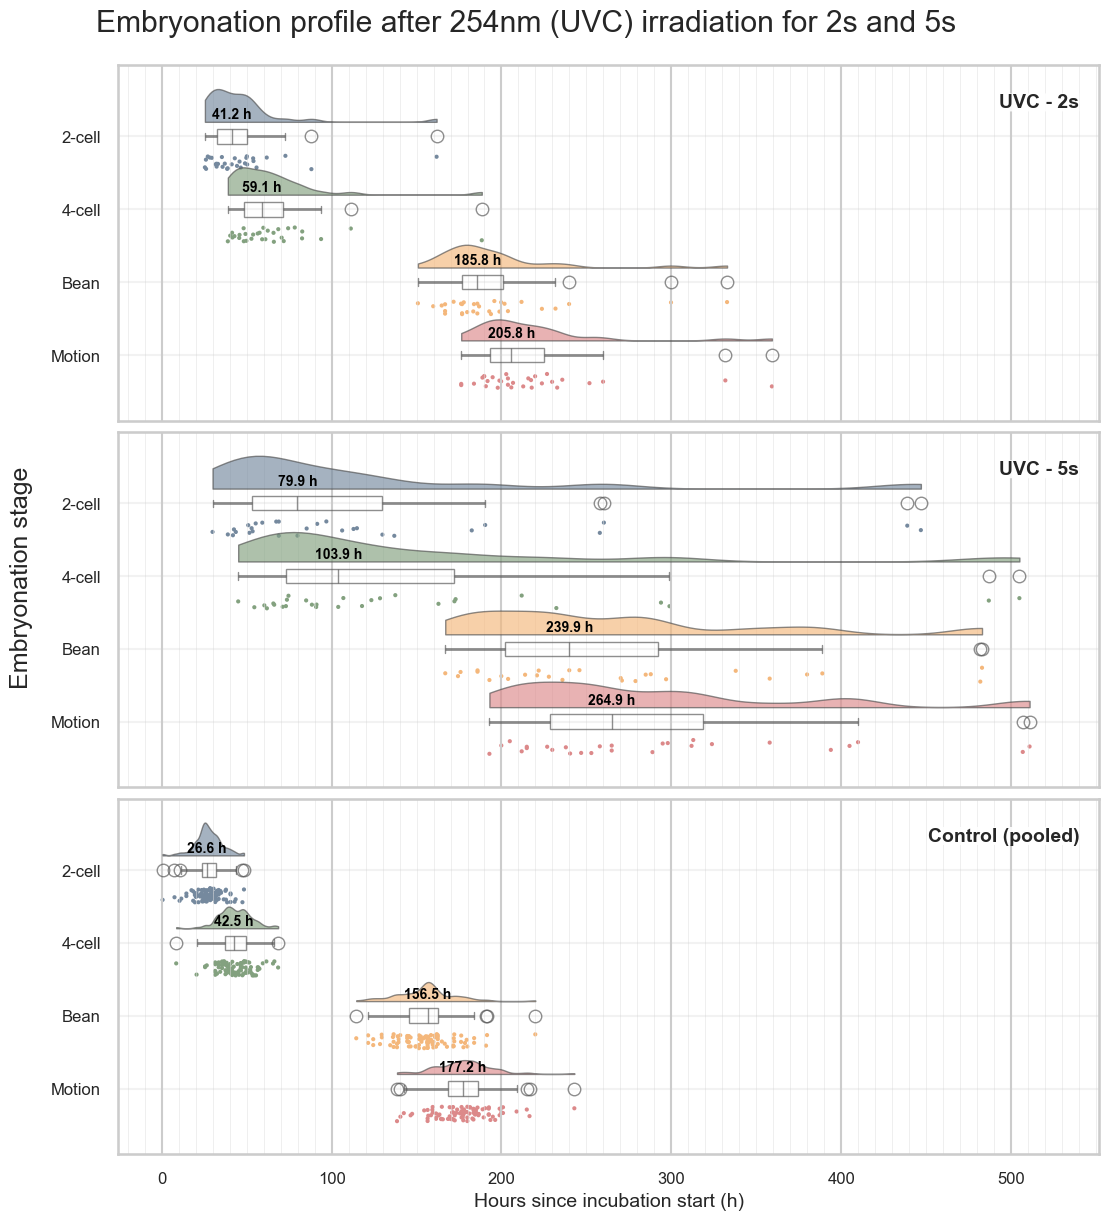

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/plots/raincloud_uvc_stage_timing_selected_vs_pooled_control.png


In [6]:
# Raincloud comparison of embryonation-stage timing across selected UVC irradiation datasets versus pooled controls

fig_caption_uvc_raincloud = (
    "Figure: Raincloud comparison of embryonation-stage timing across selected UVC irradiation datasets versus "
    "pooled controls. Panels show each selected UVC exposure group and pooled controls (control dates: "
    "2024-03-04, 2024-03-20, 2025-06-12), with a shared x-axis for direct comparison. The x-axis is elapsed "
    "time in hours from incubation start, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis "
    "shows developmental stage (2-cell, 4-cell, Bean, Motion). Each raincloud combines distribution shape "
    "(half-violin), spread and central tendency (box/IQR), and individual observations, with bold labels "
    "indicating stage-specific medians. Included eggs are restricted to VALID_OUTCOMES (non-degenerated "
    "outcomes defined earlier); stage-wise sample sizes can differ because missing stage timestamps are excluded."
)
print(fig_caption_uvc_raincloud)

if "uvc_stage_long_df" not in globals():
    raise ValueError("Run the stage table cell first.")

try:
    import ptitprince as pt
except Exception as exc:
    raise ImportError("Install `ptitprince` to render raincloud plots.") from exc

from matplotlib.ticker import MultipleLocator

group_order = selected_uvc_labels + ["pooled_control"]

def format_group_label(g: str) -> str:
    if g == "pooled_control":
        return "Control (pooled)"
    if g.startswith("uvc_"):
        parts = g.split("_")
        if len(parts) >= 3:
            return f"UVC - {parts[2]}"
    return g.replace("_", " ")

group_display_map = {g: format_group_label(g) for g in group_order}

plot_df = uvc_stage_long_df[uvc_stage_long_df["group"].isin(group_order)].copy()
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)

stage_palette = ["#75899e", "#83a17f", "#f4b77b", "#dc898a"]
label_offset_cat = -0.20
pad_top_cat = 0.12 * len(stage_order)
pad_bottom_cat = 0.10 * len(stage_order)

fig, axes = plt.subplots(len(group_order), 1, figsize=(12, 4.4 * len(group_order)), sharex=True)
if len(group_order) == 1:
    axes = [axes]

max_dt = 0.0
for ax, grp in zip(axes, group_order):
    gdf = plot_df[plot_df["group"] == grp].copy()
    if gdf.empty:
        ax.text(0.5, 0.5, f"No data for {group_display_map[grp]}", ha="center", va="center")
        ax.set_ylabel("")
        continue

    max_dt = max(max_dt, float(gdf["dt_h"].max()))

    pt.RainCloud(
        x="stage",
        y="dt_h",
        data=gdf,
        orient="h",
        order=stage_order,
        palette=stage_palette,
        bw=0.2,
        width_viol=0.9,
        width_box=0.2,
        move=0.35,
        alpha=0.65,
        dodge=False,
        pointplot=False,
        ax=ax,
    )

    medians = gdf.groupby("stage", observed=True)["dt_h"].median().reindex(stage_order)
    for y, (_, med) in enumerate(medians.items()):
        ax.text(
            med,
            y + label_offset_cat,
            f"{med:.1f} h",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            zorder=6,
        )

    ax.text(
        0.98,
        0.92,
        group_display_map[grp],
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=14,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.0",
            "facecolor": "white",
            "edgecolor": "#0C0C0C",
            "linewidth": 0.0,
            "alpha": 0.9,
        },
    )

    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)
    ax.set_ylim(-0.5 - pad_top_cat, len(stage_order) - 0.5 + pad_bottom_cat)
    ax.invert_yaxis()

axes[-1].set_xlabel("Hours since incubation start (h)", fontsize=14)
for ax in axes[:-1]:
    ax.set_xlabel("")

for ax in axes:
    pad_left = max(5, 0.05 * max_dt) if max_dt > 0 else 5
    ax.set_xlim(left=-pad_left, right=max_dt * 1.08 if max_dt > 0 else None)

fig.supylabel("Embryonation stage", x=0.07, fontsize=18)
fig.suptitle("Embryonation profile after 254nm (UVC) irradiation for 2s and 5s", y=0.93)
fig.tight_layout(rect=[0.04, 0, 1, 0.95], h_pad=0.45)

out_png = PLOTS_DIR / "raincloud_uvc_stage_timing_selected_vs_pooled_control.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


Figure: Grouped boxplot with strip overlay comparing embryonation-stage timing across selected UVC irradiation datasets and pooled controls. The x-axis is elapsed time in hours from incubation start, computed per stage as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). Boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. The legend identifies UVC exposure groups and pooled controls; pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12. Included eggs are restricted to VALID_OUTCOMES (non-degenerated outcomes defined earlier), and stage-wise sample sizes can differ because missing stage timestamps are excluded after reshaping to long format.


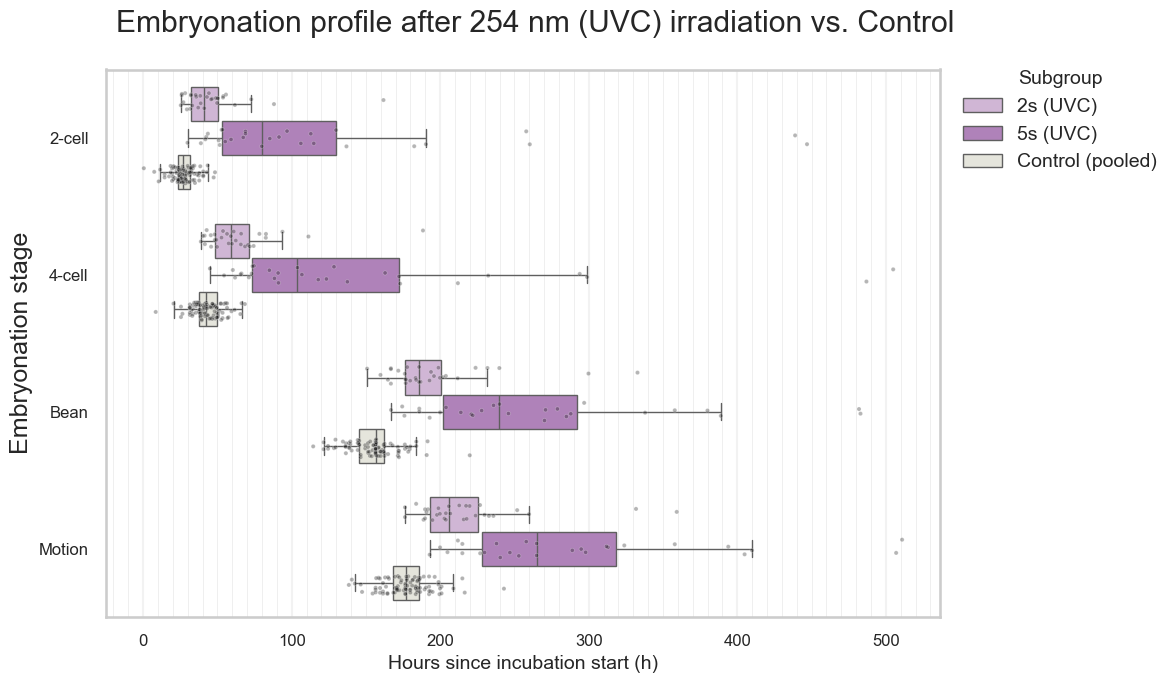

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/plots/boxplot_uvc_stage_timing_vs_pooled_control.png


In [7]:
# Compare stage timing across selected UVC datasets and pooled controls

fig_caption_uvc_stage_boxplot = (
    "Figure: Grouped boxplot with strip overlay comparing embryonation-stage timing across selected UVC irradiation "
    "datasets and pooled controls. The x-axis is elapsed time in hours from incubation start, computed per stage "
    "as dt_stage = t_stage_h - t_start_h; the y-axis shows developmental stage (2-cell, 4-cell, Bean, Motion). "
    "Boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. "
    "The legend identifies UVC exposure groups and pooled controls; pooled controls combine control dates "
    "2024-03-04, 2024-03-20, and 2025-06-12. Included eggs are restricted to VALID_OUTCOMES (non-degenerated "
    "outcomes defined earlier), and stage-wise sample sizes can differ because missing stage timestamps are excluded "
    "after reshaping to long format."
)
print(fig_caption_uvc_stage_boxplot)

if "uvc_stage_long_df" not in globals():
    raise ValueError("Run the stage table cell first.")

group_order = selected_uvc_labels + ["pooled_control"]

def format_group_label(g: str) -> str:
    if g == "pooled_control":
        return "Control (pooled)"
    if g.startswith("uvc_"):
        parts = g.split("_")
        if len(parts) >= 3:
            return f"{parts[2]} (UVC)"
    return g.replace("_", " ")

group_display_map = {g: format_group_label(g) for g in group_order}

base_colors = ["#d4b1da", "#b579c2", "#e6e6db", "#4e79a7"]
palette = {g: base_colors[i % len(base_colors)] for i, g in enumerate(group_order)}
point_palette = {g: "#000000" if g == "pooled_control" else "#0A0A0A" for g in group_order}

plot_df = uvc_stage_long_df[uvc_stage_long_df["group"].isin(group_order)].copy()
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 7.5))
sns.boxplot(
    data=plot_df,
    x="dt_h",
    y="stage",
    hue="group",
    order=stage_order,
    hue_order=group_order,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="dt_h",
    y="stage",
    hue="group",
    order=stage_order,
    hue_order=group_order,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=3,
    alpha=0.3,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

ax.set_title("")
ax.set_ylabel("Embryonation stage", fontsize=18)
ax.set_xlabel("Hours since incubation start (h)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_h = []
uniq_l = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_h.append(h)
    uniq_l.append(l)

if ax.get_legend() is not None:
    ax.get_legend().remove()

display_labels = [group_display_map.get(l, l) for l in uniq_l]
fig.legend(
    uniq_h,
    display_labels,
    title="Subgroup",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.85),
    frameon=False,
    fontsize=14,
    title_fontsize=14,
    borderaxespad=0.0,
)

fig.suptitle("Embryonation profile after 254 nm (UVC) irradiation vs. Control", y=0.92)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_uvc_stage_timing_vs_pooled_control.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


In [8]:
# Significance across selected UVC datasets and pooled control within each stage

from itertools import combinations

alpha = 0.05
group_order = selected_uvc_labels + ["pooled_control"]


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

rows = []
for stage in stage_order:
    sdf = uvc_stage_long_df[uvc_stage_long_df["stage"] == stage].copy()
    groups = [sdf.loc[sdf["group"] == g, "dt_h"].to_numpy(dtype=float) for g in group_order]
    sizes = {g: len(arr) for g, arr in zip(group_order, groups)}

    normality_p = {}
    normal_ok = True
    for g, arr in zip(group_order, groups):
        if len(arr) < 3:
            normality_p[g] = np.nan
            normal_ok = False
            continue
        p_norm = float(stats.shapiro(arr).pvalue)
        normality_p[g] = p_norm
        if p_norm < alpha:
            normal_ok = False

    if any(len(arr) == 0 for arr in groups):
        omnibus_test = "NA"
        omnibus_p = np.nan
        pair_method = "NA"
    elif normal_ok:
        omnibus_test = "ANOVA"
        omnibus_p = float(stats.f_oneway(*groups).pvalue)
        pair_method = "Welch t-test"
    else:
        omnibus_test = "Kruskal-Wallis"
        omnibus_p = float(stats.kruskal(*groups).pvalue)
        pair_method = "Mann-Whitney U"

    pair_idxs = list(combinations(range(len(group_order)), 2))
    raw_ps = []
    raw_stats = []
    pair_names = []

    for i, j in pair_idxs:
        g1, g2 = groups[i], groups[j]
        pair_names.append(f"{group_order[i]} vs {group_order[j]}")
        if len(g1) == 0 or len(g2) == 0:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)
            continue
        if pair_method == "Welch t-test":
            tst = stats.ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
            raw_stats.append(float(tst.statistic))
            raw_ps.append(float(tst.pvalue))
        elif pair_method == "Mann-Whitney U":
            mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            raw_stats.append(float(mw.statistic))
            raw_ps.append(float(mw.pvalue))
        else:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid = np.isfinite(raw_ps_arr)
    adj = np.full_like(raw_ps_arr, np.nan)
    if valid.any():
        adj[valid] = holm_adjust(raw_ps_arr[valid])

    for comp, st, p_raw, p_adj in zip(pair_names, raw_stats, raw_ps, adj):
        row = {
            "stage": stage,
            "omnibus_test": omnibus_test,
            "omnibus_p": omnibus_p,
            "pairwise_test": pair_method,
            "comparison": comp,
            "statistic": st,
            "p_raw": p_raw,
            "p_holm": p_adj,
            "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
            "sig": p_to_sig(p_adj),
        }
        for g in group_order:
            row[f"n_{g}"] = sizes.get(g, 0)
            row[f"normality_p_{g}"] = normality_p.get(g, np.nan)
        rows.append(row)

uvc_stage_stats_df = pd.DataFrame(rows).sort_values(["stage", "comparison"]).reset_index(drop=True)
display(uvc_stage_stats_df)

out_csv = TABLES_DIR / "uvc_stage_significance_selected_vs_pooled_control.csv"
uvc_stage_stats_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,stage,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig,n_uvc_6W_2s,normality_p_uvc_6W_2s,n_uvc_6W_5s,normality_p_uvc_6W_5s,n_pooled_control,normality_p_pooled_control
0,2-cell,Kruskal-Wallis,1.096131e-18,Mann-Whitney U,uvc_6W_2s vs pooled_control,2452.0,5.568664e-09,1.113733e-08,True,***,31,3.285925e-07,29,0.000004,93,0.089128
1,2-cell,Kruskal-Wallis,1.096131e-18,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,142.0,5.588047e-06,5.588047e-06,True,***,31,3.285925e-07,29,0.000004,93,0.089128
2,2-cell,Kruskal-Wallis,1.096131e-18,Mann-Whitney U,uvc_6W_5s vs pooled_control,2648.0,5.532099e-15,1.659630e-14,True,***,31,3.285925e-07,29,0.000004,93,0.089128
3,4-cell,Kruskal-Wallis,7.182713e-18,Mann-Whitney U,uvc_6W_2s vs pooled_control,2393.5,3.988428e-08,7.976855e-08,True,***,31,1.675090e-06,29,0.000008,93,0.325852
4,4-cell,Kruskal-Wallis,7.182713e-18,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,144.0,6.429283e-06,6.429283e-06,True,***,31,1.675090e-06,29,0.000008,93,0.325852
5,4-cell,Kruskal-Wallis,7.182713e-18,Mann-Whitney U,uvc_6W_5s vs pooled_control,2636.5,9.582016e-15,2.874605e-14,True,***,31,1.675090e-06,29,0.000008,93,0.325852
6,Bean,Kruskal-Wallis,8.744607e-20,Mann-Whitney U,uvc_6W_2s vs pooled_control,2621.5,9.643316e-12,1.928663e-11,True,***,31,1.137900e-05,27,0.004266,93,0.017839
7,Bean,Kruskal-Wallis,8.744607e-20,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,165.0,7.997497e-05,7.997497e-05,True,***,31,1.137900e-05,27,0.004266,93,0.017839
8,Bean,Kruskal-Wallis,8.744607e-20,Mann-Whitney U,uvc_6W_5s vs pooled_control,2461.0,3.470689e-14,1.041207e-13,True,***,31,1.137900e-05,27,0.004266,93,0.017839
9,Motion,Kruskal-Wallis,1.139899e-19,Mann-Whitney U,uvc_6W_2s vs pooled_control,2583.0,4.547002e-11,9.094003e-11,True,***,31,6.291663e-06,27,0.002800,93,0.046235


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_stage_significance_selected_vs_pooled_control.csv


In [9]:
# Post-hoc summary table for significant UVC stage comparisons (from previous cell)

if "uvc_stage_stats_df" not in globals():
    raise ValueError("Run the UVC stage significance cell first.")

uvc_stage_posthoc_sig_df = uvc_stage_stats_df[uvc_stage_stats_df["significant_0.05"]].copy()
uvc_stage_posthoc_sig_df = uvc_stage_posthoc_sig_df.sort_values(["stage", "comparison"]).reset_index(drop=True)

display(uvc_stage_posthoc_sig_df)

out_csv = TABLES_DIR / "uvc_stage_posthoc_significant_rows.csv"
uvc_stage_posthoc_sig_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,stage,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig,n_uvc_6W_2s,normality_p_uvc_6W_2s,n_uvc_6W_5s,normality_p_uvc_6W_5s,n_pooled_control,normality_p_pooled_control
0,2-cell,Kruskal-Wallis,1.096131e-18,Mann-Whitney U,uvc_6W_2s vs pooled_control,2452.0,5.568664e-09,1.113733e-08,True,***,31,3.285925e-07,29,0.000004,93,0.089128
1,2-cell,Kruskal-Wallis,1.096131e-18,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,142.0,5.588047e-06,5.588047e-06,True,***,31,3.285925e-07,29,0.000004,93,0.089128
2,2-cell,Kruskal-Wallis,1.096131e-18,Mann-Whitney U,uvc_6W_5s vs pooled_control,2648.0,5.532099e-15,1.659630e-14,True,***,31,3.285925e-07,29,0.000004,93,0.089128
3,4-cell,Kruskal-Wallis,7.182713e-18,Mann-Whitney U,uvc_6W_2s vs pooled_control,2393.5,3.988428e-08,7.976855e-08,True,***,31,1.675090e-06,29,0.000008,93,0.325852
4,4-cell,Kruskal-Wallis,7.182713e-18,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,144.0,6.429283e-06,6.429283e-06,True,***,31,1.675090e-06,29,0.000008,93,0.325852
5,4-cell,Kruskal-Wallis,7.182713e-18,Mann-Whitney U,uvc_6W_5s vs pooled_control,2636.5,9.582016e-15,2.874605e-14,True,***,31,1.675090e-06,29,0.000008,93,0.325852
6,Bean,Kruskal-Wallis,8.744607e-20,Mann-Whitney U,uvc_6W_2s vs pooled_control,2621.5,9.643316e-12,1.928663e-11,True,***,31,1.137900e-05,27,0.004266,93,0.017839
7,Bean,Kruskal-Wallis,8.744607e-20,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,165.0,7.997497e-05,7.997497e-05,True,***,31,1.137900e-05,27,0.004266,93,0.017839
8,Bean,Kruskal-Wallis,8.744607e-20,Mann-Whitney U,uvc_6W_5s vs pooled_control,2461.0,3.470689e-14,1.041207e-13,True,***,31,1.137900e-05,27,0.004266,93,0.017839
9,Motion,Kruskal-Wallis,1.139899e-19,Mann-Whitney U,uvc_6W_2s vs pooled_control,2583.0,4.547002e-11,9.094003e-11,True,***,31,6.291663e-06,27,0.002800,93,0.046235


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_stage_posthoc_significant_rows.csv


In [10]:
# Time differences (hours) for significant UVC stage post-hoc comparisons

if "uvc_stage_posthoc_sig_df" not in globals():
    raise ValueError("Run the UVC significant post-hoc table cell first.")

rows = []
for _, r in uvc_stage_posthoc_sig_df.iterrows():
    stage = r["stage"]
    g1_name, g2_name = r["comparison"].split(" vs ")

    g1 = uvc_stage_long_df[(uvc_stage_long_df["stage"] == stage) & (uvc_stage_long_df["group"] == g1_name)]["dt_h"].dropna().to_numpy(dtype=float)
    g2 = uvc_stage_long_df[(uvc_stage_long_df["stage"] == stage) & (uvc_stage_long_df["group"] == g2_name)]["dt_h"].dropna().to_numpy(dtype=float)
    if len(g1) == 0 or len(g2) == 0:
        continue

    mean_g1 = float(np.mean(g1))
    mean_g2 = float(np.mean(g2))
    med_g1 = float(np.median(g1))
    med_g2 = float(np.median(g2))
    sd_g1 = float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan
    sd_g2 = float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan

    rows.append(
        {
            "stage": stage,
            "comparison": r["comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": med_g1,
            "median_group2_h": med_g2,
            "median_diff_h_(g2-g1)": med_g2 - med_g1,
            "mean_group1_h": mean_g1,
            "mean_group2_h": mean_g2,
            "mean_diff_h_(g2-g1)": mean_g2 - mean_g1,
            "sd_group1_h": sd_g1,
            "sd_group2_h": sd_g2,
            "sd_diff_indep_h": np.sqrt(sd_g1 ** 2 + sd_g2 ** 2) if np.isfinite(sd_g1) and np.isfinite(sd_g2) else np.nan,
            "p_holm": r["p_holm"],
            "sig": r["sig"],
        }
    )

uvc_stage_sig_diffs_df = pd.DataFrame(rows).sort_values(["stage", "comparison"]).reset_index(drop=True)
display(uvc_stage_sig_diffs_df)

out_csv = TABLES_DIR / "uvc_stage_significant_time_differences.csv"
uvc_stage_sig_diffs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,stage,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,sd_diff_indep_h,p_holm,sig
0,2-cell,uvc_6W_2s vs pooled_control,31,93,41.2,26.6,-14.6,46.629032,27.446237,-19.182796,25.668076,7.999899,26.885842,1.113733e-08,***
1,2-cell,uvc_6W_2s vs uvc_6W_5s,31,29,41.2,79.9,38.7,46.629032,119.196552,72.567519,25.668076,108.199787,111.202716,5.588047e-06,***
2,2-cell,uvc_6W_5s vs pooled_control,29,93,79.9,26.6,-53.3,119.196552,27.446237,-91.750315,108.199787,7.999899,108.495126,1.659630e-14,***
3,4-cell,uvc_6W_2s vs pooled_control,31,93,59.1,42.5,-16.6,64.816129,42.979570,-21.836559,28.482955,9.943280,30.168652,7.976855e-08,***
4,4-cell,uvc_6W_2s vs uvc_6W_5s,31,29,59.1,103.9,44.8,64.816129,146.786207,81.970078,28.482955,117.844758,121.238054,6.429283e-06,***
5,4-cell,uvc_6W_5s vs pooled_control,29,93,103.9,42.5,-61.4,146.786207,42.979570,-103.806637,117.844758,9.943280,118.263501,2.874605e-14,***
6,Bean,uvc_6W_2s vs pooled_control,31,93,185.8,156.5,-29.3,195.606452,155.286022,-40.320430,38.297414,16.935707,41.874934,1.928663e-11,***
7,Bean,uvc_6W_2s vs uvc_6W_5s,31,27,185.8,239.9,54.1,195.606452,267.077778,71.471326,38.297414,87.746638,95.740088,7.997497e-05,***
8,Bean,uvc_6W_5s vs pooled_control,27,93,239.9,156.5,-83.4,267.077778,155.286022,-111.791756,87.746638,16.935707,89.366049,1.041207e-13,***
9,Motion,uvc_6W_2s vs pooled_control,31,93,205.8,177.2,-28.6,217.316129,177.533333,-39.782796,39.856560,16.931649,43.303881,9.094003e-11,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_stage_significant_time_differences.csv


In [11]:
# Per-egg stage delta table for selected UVC datasets + pooled controls

if "uvc_stage_df" not in globals():
    raise ValueError("Run the stage table build cell first.")

uvc_delta_df = uvc_stage_df.copy()
uvc_delta_df["delta_2c_4c"] = uvc_delta_df["t_4c_h"] - uvc_delta_df["t_2c_h"]
uvc_delta_df["delta_4c_bean"] = uvc_delta_df["t_bean_h"] - uvc_delta_df["t_4c_h"]
uvc_delta_df["delta_bean_move"] = uvc_delta_df["t_move_h"] - uvc_delta_df["t_bean_h"]

uvc_delta_df = uvc_delta_df.sort_values(["group", "start_date", "well_id", "egg_uid"]).reset_index(drop=True)

delta_cols = [
    "group",
    "duration_label",
    "start_date",
    "egg_uid",
    "well_id",
    "outcome",
    "delta_2c_4c",
    "delta_4c_bean",
    "delta_bean_move",
]
uvc_delta_table_df = uvc_delta_df[delta_cols].copy()
display(uvc_delta_table_df)

out_csv = TABLES_DIR / "uvc_delta_table_selected_and_pooled_control.csv"
uvc_delta_table_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,group,duration_label,start_date,egg_uid,well_id,outcome,delta_2c_4c,delta_4c_bean,delta_bean_move
0,pooled_control,control,2024-03-04,383,1,l3_reached,18.0,103.0,20.0
1,pooled_control,control,2024-03-04,384,1,l3_reached,18.0,109.0,22.0
2,pooled_control,control,2024-03-04,385,2,l3_reached,16.0,110.0,20.0
3,pooled_control,control,2024-03-04,386,2,l3_reached,15.0,102.0,21.0
4,pooled_control,control,2024-03-04,387,2,l3_reached,16.0,104.0,25.0
...,...,...,...,...,...,...,...,...,...
152,uvc_6W_5s,5s,2025-06-10,790,11,l3_reached,20.2,147.2,19.5
153,uvc_6W_5s,5s,2025-06-10,791,11,l3_reached,57.4,165.6,20.0
154,uvc_6W_5s,5s,2025-06-10,792,12,l3_reached,24.6,147.4,27.0
155,uvc_6W_5s,5s,2025-06-10,793,12,l3_reached,15.6,119.9,18.5


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_delta_table_selected_and_pooled_control.csv


Figure: Grouped boxplot with strip overlay comparing delta-stage timing across selected UVC irradiation datasets and pooled controls. The x-axis is elapsed time in hours between consecutive stages (delta_h), and the y-axis shows transition stage (2c->4c, 4c->Bean, Bean->Motion). Boxplots summarize subgroup distributions (median, IQR, whiskers), and jittered points show individual eggs. The legend identifies UVC exposure groups and pooled controls; pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12. Included eggs are restricted to VALID_OUTCOMES (non-degenerated outcomes defined earlier), with transition-wise sample sizes varying due to missing stage timestamps.


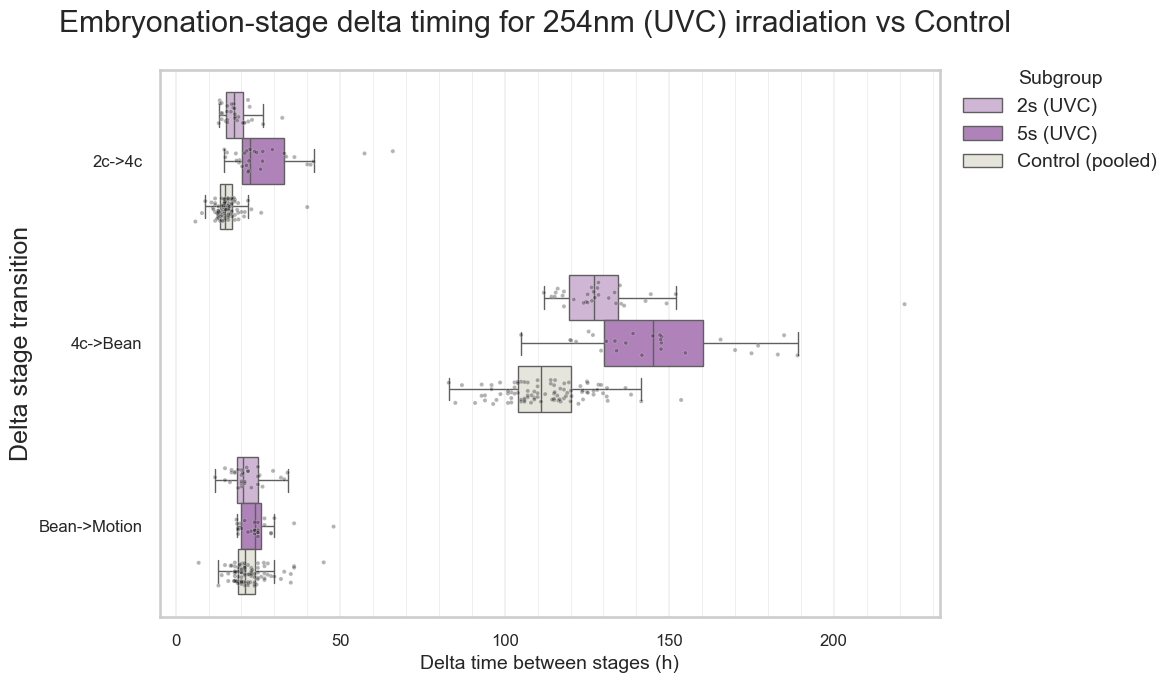

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/plots/boxplot_uvc_delta_selected_vs_pooled_control.png


In [12]:
# Compare stage-delta timing across selected UVC datasets and pooled controls

fig_caption_uvc_delta_boxplot = (
    "Figure: Grouped boxplot with strip overlay comparing delta-stage timing across selected UVC irradiation datasets "
    "and pooled controls. The x-axis is elapsed time in hours between consecutive stages (delta_h), and the y-axis "
    "shows transition stage (2c->4c, 4c->Bean, Bean->Motion). Boxplots summarize subgroup distributions (median, "
    "IQR, whiskers), and jittered points show individual eggs. The legend identifies UVC exposure groups and pooled "
    "controls; pooled controls combine control dates 2024-03-04, 2024-03-20, and 2025-06-12. Included eggs are "
    "restricted to VALID_OUTCOMES (non-degenerated outcomes defined earlier), with transition-wise sample sizes "
    "varying due to missing stage timestamps."
)
print(fig_caption_uvc_delta_boxplot)

if "uvc_delta_table_df" not in globals():
    raise ValueError("Run the UVC delta table cell first.")

delta_stage_map = {
    "delta_2c_4c": "2c->4c",
    "delta_4c_bean": "4c->Bean",
    "delta_bean_move": "Bean->Motion",
}
delta_stage_order = ["2c->4c", "4c->Bean", "Bean->Motion"]

group_order = selected_uvc_labels + ["pooled_control"]

def format_group_label(g: str) -> str:
    if g == "pooled_control":
        return "Control (pooled)"
    if g.startswith("uvc_"):
        parts = g.split("_")
        if len(parts) >= 3:
            return f"{parts[2]} (UVC)"
    return g.replace("_", " ")

group_display_map = {g: format_group_label(g) for g in group_order}

base_colors = ["#d4b1da", "#b579c2", "#e6e6db", "#4e79a7"]
palette = {g: base_colors[i % len(base_colors)] for i, g in enumerate(group_order)}
point_palette = {g: "#000000" if g == "pooled_control" else "#050505" for g in group_order}

delta_long = (
    uvc_delta_table_df.melt(
        id_vars=["egg_uid", "well_id", "group", "duration_label"],
        value_vars=["delta_2c_4c", "delta_4c_bean", "delta_bean_move"],
        var_name="delta_stage",
        value_name="delta_h",
    )
    .dropna(subset=["delta_h"])
    .copy()
)
delta_long["delta_stage"] = delta_long["delta_stage"].map(delta_stage_map)
delta_long["delta_stage"] = pd.Categorical(delta_long["delta_stage"], categories=delta_stage_order, ordered=True)
delta_long["group"] = pd.Categorical(delta_long["group"], categories=group_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 7.5))
sns.boxplot(
    data=delta_long,
    x="delta_h",
    y="delta_stage",
    hue="group",
    order=delta_stage_order,
    hue_order=group_order,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

sns.stripplot(
    data=delta_long,
    x="delta_h",
    y="delta_stage",
    hue="group",
    order=delta_stage_order,
    hue_order=group_order,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=3,
    alpha=0.3,
    linewidth=0.5,
    edgecolor="white",
    ax=ax,
)

ax.set_title("")
ax.set_ylabel("Delta stage transition", fontsize=18)
ax.set_xlabel("Delta time between stages (h)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_h = []
uniq_l = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_h.append(h)
    uniq_l.append(l)

if ax.get_legend() is not None:
    ax.get_legend().remove()

display_labels = [group_display_map.get(l, l) for l in uniq_l]
fig.legend(
    uniq_h,
    display_labels,
    title="Subgroup",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.85),
    frameon=False,
    fontsize=14,
    title_fontsize=14,
    borderaxespad=0.0,
)

fig.suptitle("Embryonation-stage delta timing for 254nm (UVC) irradiation vs Control", y=0.92)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_uvc_delta_selected_vs_pooled_control.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


In [13]:
# Significance across selected UVC datasets and pooled control within each delta group

from itertools import combinations

alpha = 0.05
group_order = selected_uvc_labels + ["pooled_control"]
delta_group_order = ["delta_2c_4c", "delta_4c_bean", "delta_bean_move"]


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

rows = []
for dcol in delta_group_order:
    groups = [
        uvc_delta_table_df.loc[uvc_delta_table_df["group"] == g, dcol].dropna().to_numpy(dtype=float)
        for g in group_order
    ]
    sizes = {g: len(arr) for g, arr in zip(group_order, groups)}

    normality_p = {}
    all_groups_normal = True
    for g, arr in zip(group_order, groups):
        if len(arr) < 3:
            normality_p[g] = np.nan
            all_groups_normal = False
            continue
        p_norm = float(stats.shapiro(arr).pvalue)
        normality_p[g] = p_norm
        if p_norm < alpha:
            all_groups_normal = False

    if any(len(arr) == 0 for arr in groups):
        omnibus_test = "NA"
        omnibus_p = np.nan
        pair_method = "NA"
    elif all_groups_normal:
        omnibus_test = "ANOVA"
        omnibus_p = float(stats.f_oneway(*groups).pvalue)
        pair_method = "Welch t-test"
    else:
        omnibus_test = "Kruskal-Wallis"
        omnibus_p = float(stats.kruskal(*groups).pvalue)
        pair_method = "Mann-Whitney U"

    pair_idxs = list(combinations(range(len(group_order)), 2))
    raw_ps = []
    raw_stats = []
    pair_names = []
    for i, j in pair_idxs:
        g1, g2 = groups[i], groups[j]
        pair_names.append(f"{group_order[i]} vs {group_order[j]}")
        if len(g1) == 0 or len(g2) == 0:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)
            continue
        if pair_method == "Welch t-test":
            tst = stats.ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
            raw_stats.append(float(tst.statistic))
            raw_ps.append(float(tst.pvalue))
        elif pair_method == "Mann-Whitney U":
            mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            raw_stats.append(float(mw.statistic))
            raw_ps.append(float(mw.pvalue))
        else:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid = np.isfinite(raw_ps_arr)
    adj = np.full_like(raw_ps_arr, np.nan)
    if valid.any():
        adj[valid] = holm_adjust(raw_ps_arr[valid])

    for comp, st, p_raw, p_adj in zip(pair_names, raw_stats, raw_ps, adj):
        row = {
            "delta_group": dcol,
            "omnibus_test": omnibus_test,
            "omnibus_p": omnibus_p,
            "pairwise_test": pair_method,
            "comparison": comp,
            "statistic": st,
            "p_raw": p_raw,
            "p_holm": p_adj,
            "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
            "sig": p_to_sig(p_adj),
        }
        for g in group_order:
            row[f"n_{g}"] = sizes.get(g, 0)
            row[f"normality_p_{g}"] = normality_p.get(g, np.nan)
        rows.append(row)

uvc_delta_stats_df = pd.DataFrame(rows).sort_values(["delta_group", "comparison"]).reset_index(drop=True)
display(uvc_delta_stats_df)

out_csv = TABLES_DIR / "uvc_delta_significance_selected_vs_pooled_control.csv"
uvc_delta_stats_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,delta_group,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig,n_uvc_6W_2s,normality_p_uvc_6W_2s,n_uvc_6W_5s,normality_p_uvc_6W_5s,n_pooled_control,normality_p_pooled_control
0,delta_2c_4c,Kruskal-Wallis,4.026570e-12,Mann-Whitney U,uvc_6W_2s vs pooled_control,2023.5,7.797706e-04,7.797706e-04,True,***,31,3.527954e-03,29,0.000175,93,2.395967e-10
1,delta_2c_4c,Kruskal-Wallis,4.026570e-12,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,165.0,2.652656e-05,5.305312e-05,True,***,31,3.527954e-03,29,0.000175,93,2.395967e-10
2,delta_2c_4c,Kruskal-Wallis,4.026570e-12,Mann-Whitney U,uvc_6W_5s vs pooled_control,2475.0,1.196471e-11,3.589412e-11,True,***,31,3.527954e-03,29,0.000175,93,2.395967e-10
3,delta_4c_bean,Kruskal-Wallis,1.604047e-14,Mann-Whitney U,uvc_6W_2s vs pooled_control,2403.0,2.918734e-08,5.837468e-08,True,***,31,2.769489e-07,27,0.224454,93,7.694534e-01
4,delta_4c_bean,Kruskal-Wallis,1.604047e-14,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,213.0,1.394573e-03,1.394573e-03,True,**,31,2.769489e-07,27,0.224454,93,7.694534e-01
5,delta_4c_bean,Kruskal-Wallis,1.604047e-14,Mann-Whitney U,uvc_6W_5s vs pooled_control,2314.0,2.931715e-11,8.795145e-11,True,***,31,2.769489e-07,27,0.224454,93,7.694534e-01
6,delta_bean_move,Kruskal-Wallis,7.778514e-02,Mann-Whitney U,uvc_6W_2s vs pooled_control,1341.0,5.630760e-01,5.630760e-01,False,ns,31,8.636687e-02,27,0.000081,93,3.809887e-06
7,delta_bean_move,Kruskal-Wallis,7.778514e-02,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,300.5,6.625809e-02,1.325162e-01,False,ns,31,8.636687e-02,27,0.000081,93,3.809887e-06
8,delta_bean_move,Kruskal-Wallis,7.778514e-02,Mann-Whitney U,uvc_6W_5s vs pooled_control,1590.5,3.518896e-02,1.055669e-01,False,ns,31,8.636687e-02,27,0.000081,93,3.809887e-06


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_delta_significance_selected_vs_pooled_control.csv


In [14]:
# Post-hoc table for significant UVC delta comparisons (from previous cell)

if "uvc_delta_stats_df" not in globals():
    raise ValueError("Run the UVC delta significance cell first.")

uvc_delta_posthoc_sig_df = uvc_delta_stats_df[uvc_delta_stats_df["significant_0.05"]].copy()
uvc_delta_posthoc_sig_df = uvc_delta_posthoc_sig_df.sort_values(["delta_group", "comparison"]).reset_index(drop=True)

display(uvc_delta_posthoc_sig_df)

out_csv = TABLES_DIR / "uvc_delta_posthoc_significant_rows.csv"
uvc_delta_posthoc_sig_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,delta_group,omnibus_test,omnibus_p,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,sig,n_uvc_6W_2s,normality_p_uvc_6W_2s,n_uvc_6W_5s,normality_p_uvc_6W_5s,n_pooled_control,normality_p_pooled_control
0,delta_2c_4c,Kruskal-Wallis,4.026570e-12,Mann-Whitney U,uvc_6W_2s vs pooled_control,2023.5,7.797706e-04,7.797706e-04,True,***,31,3.527954e-03,29,0.000175,93,2.395967e-10
1,delta_2c_4c,Kruskal-Wallis,4.026570e-12,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,165.0,2.652656e-05,5.305312e-05,True,***,31,3.527954e-03,29,0.000175,93,2.395967e-10
2,delta_2c_4c,Kruskal-Wallis,4.026570e-12,Mann-Whitney U,uvc_6W_5s vs pooled_control,2475.0,1.196471e-11,3.589412e-11,True,***,31,3.527954e-03,29,0.000175,93,2.395967e-10
3,delta_4c_bean,Kruskal-Wallis,1.604047e-14,Mann-Whitney U,uvc_6W_2s vs pooled_control,2403.0,2.918734e-08,5.837468e-08,True,***,31,2.769489e-07,27,0.224454,93,7.694534e-01
4,delta_4c_bean,Kruskal-Wallis,1.604047e-14,Mann-Whitney U,uvc_6W_2s vs uvc_6W_5s,213.0,1.394573e-03,1.394573e-03,True,**,31,2.769489e-07,27,0.224454,93,7.694534e-01
5,delta_4c_bean,Kruskal-Wallis,1.604047e-14,Mann-Whitney U,uvc_6W_5s vs pooled_control,2314.0,2.931715e-11,8.795145e-11,True,***,31,2.769489e-07,27,0.224454,93,7.694534e-01


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_delta_posthoc_significant_rows.csv


In [15]:
# Time differences (hours) for significant UVC delta post-hoc comparisons

if "uvc_delta_posthoc_sig_df" not in globals():
    raise ValueError("Run the UVC delta significant post-hoc table cell first.")

rows = []
for _, r in uvc_delta_posthoc_sig_df.iterrows():
    dcol = r["delta_group"]
    g1_name, g2_name = r["comparison"].split(" vs ")

    g1 = uvc_delta_table_df[uvc_delta_table_df["group"] == g1_name][dcol].dropna().to_numpy(dtype=float)
    g2 = uvc_delta_table_df[uvc_delta_table_df["group"] == g2_name][dcol].dropna().to_numpy(dtype=float)
    if len(g1) == 0 or len(g2) == 0:
        continue

    mean_g1 = float(np.mean(g1))
    mean_g2 = float(np.mean(g2))
    med_g1 = float(np.median(g1))
    med_g2 = float(np.median(g2))
    sd_g1 = float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan
    sd_g2 = float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan

    rows.append(
        {
            "delta_group": dcol,
            "comparison": r["comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": med_g1,
            "median_group2_h": med_g2,
            "median_diff_h_(g2-g1)": med_g2 - med_g1,
            "mean_group1_h": mean_g1,
            "mean_group2_h": mean_g2,
            "mean_diff_h_(g2-g1)": mean_g2 - mean_g1,
            "sd_group1_h": sd_g1,
            "sd_group2_h": sd_g2,
            "sd_diff_indep_h": np.sqrt(sd_g1 ** 2 + sd_g2 ** 2) if np.isfinite(sd_g1) and np.isfinite(sd_g2) else np.nan,
            "p_holm": r["p_holm"],
            "sig": r["sig"],
        }
    )

uvc_delta_sig_diffs_df = pd.DataFrame(rows).sort_values(["delta_group", "comparison"]).reset_index(drop=True)
display(uvc_delta_sig_diffs_df)

out_csv = TABLES_DIR / "uvc_delta_significant_time_differences.csv"
uvc_delta_sig_diffs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,delta_group,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,sd_diff_indep_h,p_holm,sig
0,delta_2c_4c,uvc_6W_2s vs pooled_control,31,93,17.7,15.0,-2.7,18.187097,15.533333,-2.653763,4.264484,3.902071,5.780310,7.797706e-04,***
1,delta_2c_4c,uvc_6W_2s vs uvc_6W_5s,31,29,17.7,22.6,4.9,18.187097,27.589655,9.402558,4.264484,12.135495,12.862973,5.305312e-05,***
2,delta_2c_4c,uvc_6W_5s vs pooled_control,29,93,22.6,15.0,-7.6,27.589655,15.533333,-12.056322,12.135495,3.902071,12.747408,3.589412e-11,***
3,delta_4c_bean,uvc_6W_2s vs pooled_control,31,93,127.0,111.0,-16.0,130.790323,112.306452,-18.483871,19.647330,12.957596,23.535439,5.837468e-08,***
4,delta_4c_bean,uvc_6W_2s vs uvc_6W_5s,31,27,127.0,145.0,18.0,130.790323,146.151852,15.361529,19.647330,22.318126,29.734094,1.394573e-03,**
5,delta_4c_bean,uvc_6W_5s vs pooled_control,27,93,145.0,111.0,-34.0,146.151852,112.306452,-33.845400,22.318126,12.957596,25.806938,8.795145e-11,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/254nm/unembryonated/tables/uvc_delta_significant_time_differences.csv
